In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
# Install Kaggle
!pip install -q kaggle

import os

# Kaggle credentials
os.environ['KAGGLE_USERNAME'] = 'jyotirmayabehera'
os.environ['KAGGLE_KEY'] = 'KGAT_fa1af098d41a2070af04c51319501a08'

# Download dataset
!kaggle datasets download -d robiulhasanjisan/leaf-vs-non-leaf-images

# Extract dataset
!unzip -q leaf-vs-non-leaf-images.zip -d leaf_dataset

print("Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/robiulhasanjisan/leaf-vs-non-leaf-images
License(s): MIT
100% 2.25G/2.25G [02:17<00:00, 17.5MB/s]

Dataset downloaded and extracted successfully!


In [ ]:
DATASET_DIR = '/content/leaf_dataset'

In [ ]:
print(os.listdir(DATASET_DIR))

['non_leaf', 'leaf']


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 10400 images belonging to 2 classes.
Found 2600 images belonging to 2 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/30
 33/325 ━━━━━━━━━━━━━━━━━━━━ 1:36 330ms/step - accuracy: 0.6008 - loss: 0.9675

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


325/325 ━━━━━━━━━━━━━━━━━━━━ 129s 372ms/step - accuracy: 0.9025 - loss: 0.2507 - val_accuracy: 0.9577 - val_loss: 0.1169
Epoch 2/30
325/325 ━━━━━━━━━━━━━━━━━━━━ 109s 337ms/step - accuracy: 0.9606 - loss: 0.1219 - val_accuracy: 0.9508 - val_loss: 0.1187
Epoch 3/30
325/325 ━━━━━━━━━━━━━━━━━━━━ 109s 335ms/step - accuracy: 0.9650 - loss: 0.1005 - val_accuracy: 0.9400 - val_loss: 0.1840
Epoch 4/30
325/325 ━━━━━━━━━━━━━━━━━━━━ 108s 334ms/step - accuracy: 0.9705 - loss: 0.0907 - val_accuracy: 0.9485 - val_loss: 0.1269
Epoch 5/30
325/325 ━━━━━━━━━━━━━━━━━━━━ 110s 338ms/step - accuracy: 0.9756 - loss: 0.0712 - val_accuracy: 0.9323 - val_loss: 0.2252
Epoch 6/30
325/325 ━━━━━━━━━━━━━━━━━━━━ 109s 337ms/step - accuracy: 0.9834 - loss: 0.0510 - val_accuracy: 0.9454 - val_loss: 0.1545
Epoch 7/30
325/325 ━━━━━━━━━━━━━━━━━━━━ 109s 337ms/step - accuracy: 0.9821 - loss: 0.0478 - val_accuracy: 0.9177 - val_loss: 0.2444
Epoch 8/30
325/325 ━━━━━━━━━━━━━━━━━━━━ 125s 384ms/step - accuracy: 0.9826 - loss: 0.04

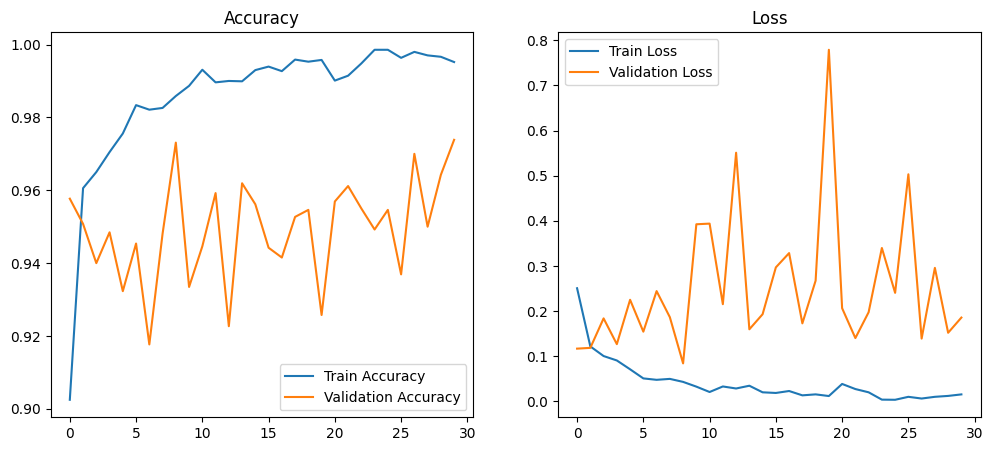

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
val_loss, val_accuracy = model.evaluate(val_generator)

print(f"\nFinal Validation Accuracy: {val_accuracy * 100:.2f}%")

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc * 100:.2f}%")
print(f"Final Validation Accuracy (Last Epoch): {val_acc * 100:.2f}%")

best_val_acc = max(history.history['val_accuracy'])
print(f"Best Validation Accuracy Achieved: {best_val_acc * 100:.2f}%")

82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 348ms/step - accuracy: 0.9738 - loss: 0.1858

Final Validation Accuracy: 97.38%
Final Training Accuracy: 99.52%
Final Validation Accuracy (Last Epoch): 97.38%
Best Validation Accuracy Achieved: 97.38%


In [ ]:
plt.figure(figsize=(5,4))
plt.bar(['Training', 'Validation'], [train_acc, val_acc])
plt.title('Final Model Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

In [ ]:
print("\nClass Indices:")
print(train_generator.class_indices)

In [ ]:
class_names = ['leaf', 'non_leaf']

In [ ]:
import numpy as np

def predict(model, img):
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0][0]

    if prediction > 0.5:
        predicted_class = class_names[1]
        confidence = prediction * 100
    else:
        predicted_class = class_names[0]
        confidence = (1 - prediction) * 100

    return predicted_class, round(confidence, 2)

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 13000 files belonging to 2 classes.


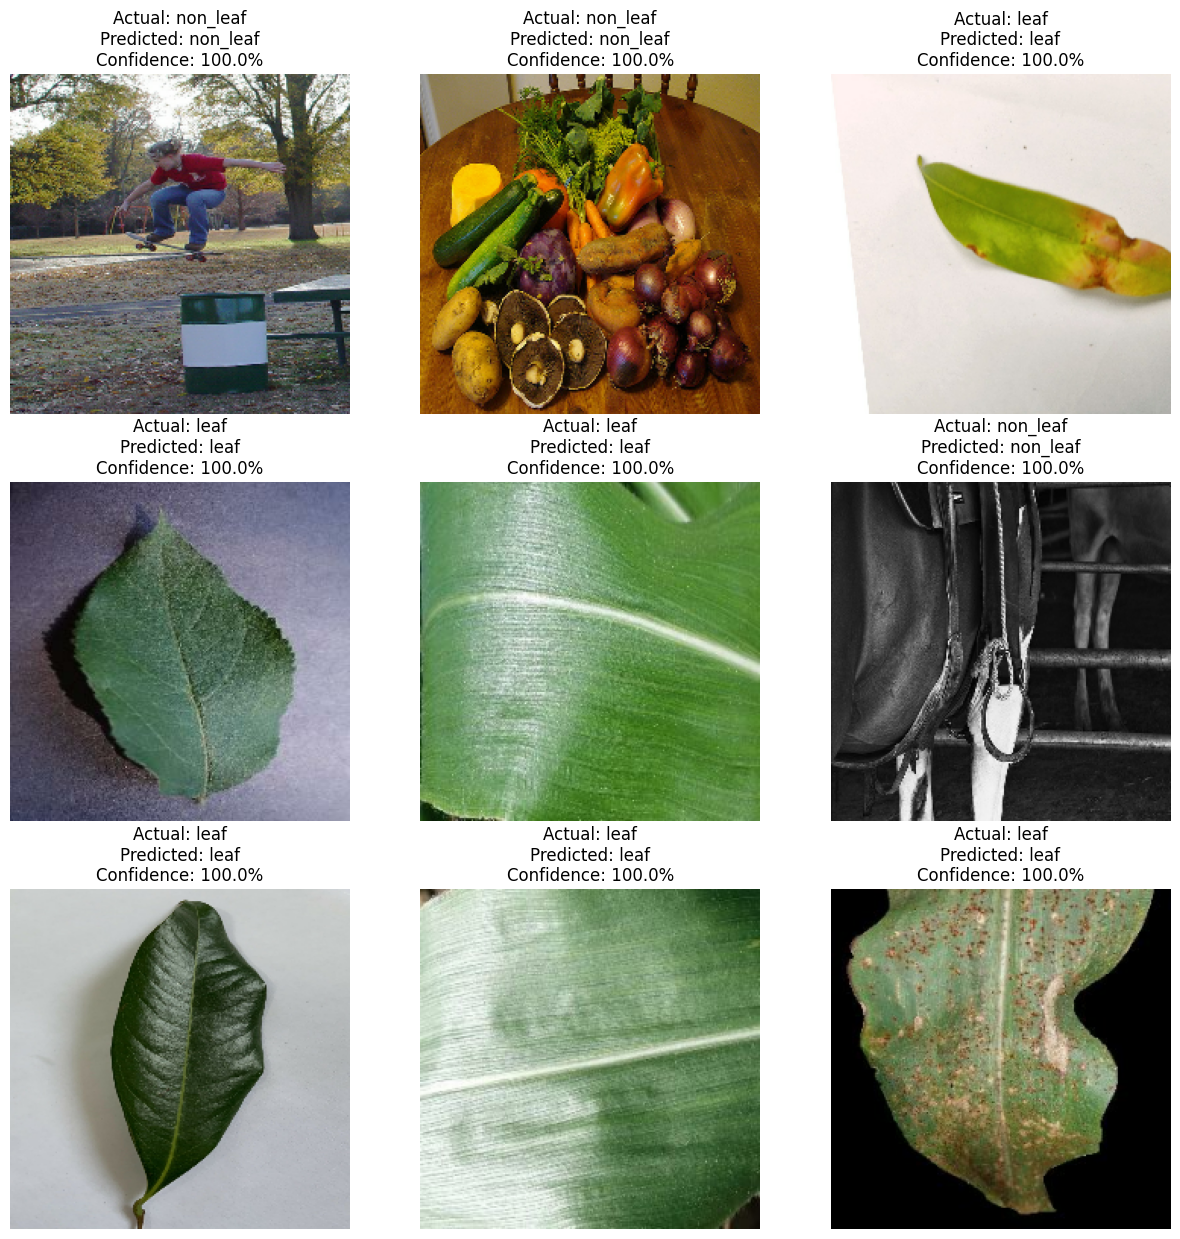

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence}%"
        )

        plt.axis("off")

plt.show()

In [ ]:
model.save("leaf_vs_non_leaf_model.keras")

In [ ]:
#download save model
from google.colab import files

files.download("leaf_vs_non_leaf_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>